# LLM Fine-Tuning with QLoRA + DPO

**Techniques covered:** QLoRA (4-bit quantization + LoRA), Supervised Fine-Tuning (SFT), Direct Preference Optimization (DPO)

**Model:** Mistral-7B-Instruct-v0.3 (or any model from HuggingFace Hub)

**Hardware:** Google Colab / Kaggle T4 free GPU (16 GB VRAM)

---

## How the Pipeline Works

```
Dataset  →  Load Base Model (4-bit)  →  Attach LoRA  →  SFT Training
         →  DPO Alignment  →  Evaluate (ROUGE, BERTScore, Perplexity)
         →  Before vs After Comparison  →  Push to HuggingFace Hub
```

## Where You Can Make Changes


| What | Variable | Options |
|------|----------|---------|
| Base model | `MODEL_ID` | `mistralai/Mistral-7B-Instruct-v0.3`, `meta-llama/Llama-3.2-3B-Instruct`, `google/gemma-2-2b-it` |
| Dataset | `DATASET_NAME` | Any HuggingFace dataset or path to your JSONL |
| LoRA rank | `LORA_R` | 8 (fast/small), 16 (balanced), 32 (high capacity) |
| Epochs | `NUM_EPOCHS` | 1-5 (1-2 for quick experiments) |
| Max sequence length | `MAX_SEQ_LENGTH` | 512, 1024, 2048 |

---

## Check GPU
First, confirm you have a GPU. In Colab: Runtime → Change Runtime Type → T4 GPU. In Kaggle: Settings → Accelerator → GPU T4.

In [1]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else 'No GPU found. Go to Runtime → Change Runtime Type → GPU')

Fri Apr  3 12:25:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Install Dependencies

- `transformers` — HuggingFace model loading and tokenizer
- `peft` — Parameter-Efficient Fine-Tuning (LoRA/QLoRA)
- `trl` — SFTTrainer and DPOTrainer (from HuggingFace)
- `bitsandbytes` — 4-bit quantization engine for QLoRA
- `datasets` — loading and processing datasets
- `accelerate` — distributed training utility
- `evaluate` / `rouge_score` / `bert_score` — evaluation metrics
- `wandb` — experiment tracking (optional but professional)
- `gradio` — interactive demo UI

In [2]:
!pip install -q transformers
!pip install -q peft
!pip install -U trl
!pip install -U bitsandbytes
!pip install -q datasets
!pip install -q accelerate
!pip install -q evaluate rouge_score bert_score
!pip install -q sentencepiece protobuf
!pip install -q gradio
!pip install -q huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 20.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.2 MB/s eta 0:00:00


## Configuration (All Changes Here)

This is the **single place** to configure your entire experiment. Modify this cell to:
- Switch models
- Switch datasets
- Tune LoRA rank, batch size, epochs
- Toggle DPO on/off

In [ ]:
from dataclasses import dataclass

@dataclass
class Config:

    MODEL_ID: str = 'HuggingFaceH4/zephyr-7b-beta'
    DATASET_NAME: str = 'bitext/Bitext-customer-support-llm-chatbot-training-dataset'

    LORA_R: int = 16
    LORA_ALPHA: int = 32
    LORA_DROPOUT: float = 0.05
    TARGET_MODULES: list = None

    MAX_SEQ_LENGTH: int = 512       # Reduce to 256 if OOM
    NUM_EPOCHS: int = 1             # 1 epoch = fast experiment. Use 3 for real training.
    BATCH_SIZE: int = 2             # Keep at 2 for T4
    GRAD_ACCUM: int = 4             # Effective batch = BATCH_SIZE × GRAD_ACCUM = 8
    LEARNING_RATE: float = 2e-4
    MAX_TRAIN_SAMPLES: int = 200   # Set to None to use full dataset
    MAX_EVAL_SAMPLES: int = 5

    RUN_DPO: bool = False           # Set True to run DPO after SFT (needs preference dataset)
    DPO_BETA: float = 0.1           # DPO temperature (0.1-0.5)

    # Output paths
    SFT_OUTPUT_DIR: str = './sft_output'
    DPO_OUTPUT_DIR: str = './dpo_output'
    EVAL_RESULTS_PATH: str = './eval_results.json'

    HF_TOKEN: str = 'hf_xxxxxxxx'              # Paste your HF token to push model to Hub
    PUSH_TO_HUB: bool = True                   # Put False if don't want to push to Hub
    HUB_MODEL_ID: str = 'username/finetuned-model-name'

    def __post_init__(self):
        if self.TARGET_MODULES is None:
            # Auto-select LoRA target modules based on model architecture
            if 'mistral' in self.MODEL_ID.lower() or 'zephyr' in self.MODEL_ID.lower():
                self.TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
            elif 'llama' in self.MODEL_ID.lower():
                self.TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
            elif 'gemma' in self.MODEL_ID.lower():
                self.TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']
            else:
                self.TARGET_MODULES = ['q_proj', 'v_proj']  # Safe default

cfg = Config()

print('  CONFIGURATION SUMMARY')
print(f'  Model          : {cfg.MODEL_ID}')
print(f'  Dataset        : {cfg.DATASET_NAME}')
print(f'  LoRA rank      : {cfg.LORA_R}')
print(f'  LoRA alpha     : {cfg.LORA_ALPHA}')
print(f'  Target modules : {cfg.TARGET_MODULES}')
print(f'  Max seq len    : {cfg.MAX_SEQ_LENGTH}')
print(f'  Epochs         : {cfg.NUM_EPOCHS}')
print(f'  Batch size     : {cfg.BATCH_SIZE} × grad accum {cfg.GRAD_ACCUM}')
print(f'  Learning rate  : {cfg.LEARNING_RATE}')
print(f'  Train samples  : {cfg.MAX_TRAIN_SAMPLES}')
print(f'  Run DPO        : {cfg.RUN_DPO}')

  CONFIGURATION SUMMARY
  Model          : HuggingFaceH4/zephyr-7b-beta
  Dataset        : bitext/Bitext-customer-support-llm-chatbot-training-dataset
  LoRA rank      : 16
  LoRA alpha     : 32
  Target modules : ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
  Max seq len    : 512
  Epochs         : 1
  Batch size     : 2 × grad accum 4
  Learning rate  : 0.0002
  Train samples  : 200
  Run DPO        : False


## Imports

All imports in one place. If any fail, re-run Cell 1.

In [6]:
import os, json, time, warnings
import torch
import numpy as np
from datasets import load_dataset, Dataset
from transformers import (
    AutoModelForCausalLM, AutoTokenizer,
    BitsAndBytesConfig, TrainingArguments,
    GenerationConfig, set_seed
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer, DPOTrainer, DPOConfig
import evaluate

warnings.filterwarnings('ignore')
set_seed(42)

# Device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'Total VRAM: {total:.1f} GB')
else:
    print('No GPU found. Training will be very slow.')

Device: cuda
GPU: Tesla T4
Total VRAM: 15.6 GB


## Dataset Loading & Preprocessing

### Concept: Instruction-response pairs
Fine-tuning requires structured data in the format:
```
{"instruction": "What is your refund policy?",
 "response": "Our refund policy allows returns within 30 days..."}
```

We convert this into a **chat template** that matches what the model was pre-trained on.
For Mistral/Zephyr this looks like:
```
<|user|> What is your refund policy? </s>
<|assistant|> Our refund policy... </s>
```

### Adding your own dataset
Replace the `load_from_huggingface()` call with:
```python
dataset = load_dataset('json', data_files={'train': 'your_data.jsonl'})
```
Your JSONL needs at minimum `instruction` and `response` (or `output`) columns.

In [7]:
def load_and_prepare_dataset(cfg):
    """Load dataset from HuggingFace Hub and normalize to instruction/response format."""
    print(f'Loading dataset: {cfg.DATASET_NAME}')

    raw = load_dataset(cfg.DATASET_NAME, trust_remote_code=True)
    print(f'Raw dataset splits: {list(raw.keys())}')
    print(f'Columns: {raw[list(raw.keys())[0]].column_names}')

    # Normalize different dataset formats into a unified schema
    def normalize_row(row):
        """
        Handles multiple dataset column naming conventions:
        - bitext: instruction, response
        - dolly: instruction, response, context
        - alpaca: instruction, input, output
        - openorca: system_prompt, question, response
        """
        instruction = (
            row.get('instruction') or
            row.get('question') or
            row.get('prompt') or
            row.get('input', '')
        )
        response = (
            row.get('response') or
            row.get('output') or
            row.get('answer') or
            row.get('completion', '')
        )
        context = row.get('context', '') or row.get('system_prompt', '')
        return {
            'instruction': str(instruction).strip(),
            'response': str(response).strip(),
            'context': str(context).strip()
        }

    # Use train split; fall back to first available
    split_name = 'train' if 'train' in raw else list(raw.keys())[0]
    train_data = raw[split_name]

    # Limit samples for fast experimentation
    if cfg.MAX_TRAIN_SAMPLES:
        train_data = train_data.select(range(min(cfg.MAX_TRAIN_SAMPLES, len(train_data))))

    # Create eval split
    split = train_data.train_test_split(test_size=0.1, seed=42)
    train_ds = split['train'].map(normalize_row, remove_columns=train_data.column_names)
    eval_ds  = split['test'].map(normalize_row, remove_columns=train_data.column_names)

    if cfg.MAX_EVAL_SAMPLES:
        eval_ds = eval_ds.select(range(min(cfg.MAX_EVAL_SAMPLES, len(eval_ds))))

    # Filter out empty rows
    train_ds = train_ds.filter(lambda x: len(x['instruction']) > 5 and len(x['response']) > 5)
    eval_ds  = eval_ds.filter(lambda x: len(x['instruction']) > 5 and len(x['response']) > 5)

    print(f'\nDataset ready: {len(train_ds)} train | {len(eval_ds)} eval')
    print('\n--- Sample row ---')
    sample = train_ds[0]
    print(f'Instruction: {sample["instruction"][:120]}...')
    print(f'Response:    {sample["response"][:120]}...')
    return train_ds, eval_ds

train_ds, eval_ds = load_and_prepare_dataset(cfg)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'bitext/Bitext-customer-support-llm-chatbot-training-dataset' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'bitext/Bitext-customer-support-llm-chatbot-training-dataset' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading dataset: bitext/Bitext-customer-support-llm-chatbot-training-dataset


README.md: 0.00B [00:00, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/180 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Filter:   0%|          | 0/180 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5 [00:00<?, ? examples/s]


Dataset ready: 180 train | 5 eval

--- Sample row ---
Instruction: i need assistance canceling order {{Order Number}}...
Response:    I'm clearly cognizant your need for assistance in canceling your order with the order number {{Order Number}}. We are he...


## Load Tokenizer

### Concept: Tokenizer & chat templates
A tokenizer converts text → numbers (token IDs) that the model processes.
Each model family has its own **chat template** that wraps instructions in special tokens.
We use `apply_chat_template()` to format data correctly for the chosen model.

In [8]:
def load_tokenizer(cfg):
    print(f'Loading tokenizer: {cfg.MODEL_ID}')
    tokenizer = AutoTokenizer.from_pretrained(
        cfg.MODEL_ID,
        trust_remote_code=True,
        token=cfg.HF_TOKEN if cfg.HF_TOKEN else None
    )
    # Many causal models don't have a pad token — set it to eos_token
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id
    tokenizer.padding_side = 'right'  # Required for SFT

    print(f'Vocab size: {tokenizer.vocab_size:,}')
    print(f'EOS token: {tokenizer.eos_token!r}')
    print(f'PAD token: {tokenizer.pad_token!r}')

    # Test the chat template
    test_messages = [
        {'role': 'user', 'content': 'What is your return policy?'},
        {'role': 'assistant', 'content': 'You can return items within 30 days.'}
    ]
    try:
        formatted = tokenizer.apply_chat_template(test_messages, tokenize=False)
        print(f'\nChat template sample:\n{formatted[:200]}...')
    except Exception as e:
        print(f'Note: Chat template not available ({e}). Using manual formatting.')

    return tokenizer


tokenizer = load_tokenizer(cfg)


def format_prompt(row, tokenizer, include_response=True):
    """
    Format a row into a chat-templated string.
    This is what the model actually sees during training.
    """
    messages = []
    if row.get('context'):
        messages.append({'role': 'system', 'content': row['context']})
    messages.append({'role': 'user', 'content': row['instruction']})
    if include_response:
        messages.append({'role': 'assistant', 'content': row['response']})

    try:
        return tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=not include_response
        )
    except:
        # Fallback manual template for models without chat template
        text = ''
        if row.get('context'):
            text += f"System: {row['context']}\n\n"
        text += f"User: {row['instruction']}\n\nAssistant: "
        if include_response:
            text += row['response']
        return text


# Preview formatted prompt
print('\n--- Formatted training example ---')
print(format_prompt(train_ds[0], tokenizer)[:400])

Loading tokenizer: HuggingFaceH4/zephyr-7b-beta


config.json:   0%|          | 0.00/638 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

Vocab size: 32,000
EOS token: '</s>'
PAD token: '</s>'

Chat template sample:
<|user|>
What is your return policy?</s>
<|assistant|>
You can return items within 30 days.</s>
...

--- Formatted training example ---
<|user|>
i need assistance canceling order {{Order Number}}</s>
<|assistant|>
I'm clearly cognizant your need for assistance in canceling your order with the order number {{Order Number}}. We are here to help you navigate through the cancellation process smoothly.

To cancel your order, follow these steps:

1. Log in to your {{Online Company Portal Info}} using your credentials.
2. Go to the "{{On


## Load Base Model (4-bit Quantized)

### Concept: QLoRA = Quantization + LoRA
**4-bit quantization (QLoRA)** compresses model weights from 16-bit floats → 4-bit integers.
- A 7B model normally needs ~14 GB at bfloat16
- With 4-bit NF4: ~3.5 GB
- LoRA adapters add ~100 MB
- Total: ~4–5 GB base + ~5 GB activations = fits in 16 GB T4

**NF4 (NormalFloat4)** is a special 4-bit format that minimizes quantization error for normally-distributed weights (which LLM weights typically follow).

In [9]:
def load_base_model(cfg):
    print(f'Loading model: {cfg.MODEL_ID}')

    # 4-bit quantization config (QLoRA)
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,                    # Load weights as 4-bit integers
        bnb_4bit_quant_type='nf4',            # NormalFloat4 — best for LLM weights
        bnb_4bit_use_double_quant=True,        # Quantize the quantization constants too (saves 0.3 bpp)
        bnb_4bit_compute_dtype=torch.bfloat16  # Compute in bfloat16 during forward pass
    )

    model = AutoModelForCausalLM.from_pretrained(
        cfg.MODEL_ID,
        quantization_config=bnb_config,
        device_map='auto',           # Auto-place layers across available GPUs/CPU
        trust_remote_code=True,
        token=cfg.HF_TOKEN if cfg.HF_TOKEN else None,
        torch_dtype=torch.bfloat16,
    )

    # Required step before adding LoRA to a quantized model
    model = prepare_model_for_kbit_training(model)

    # Print memory usage
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1e9
        reserved  = torch.cuda.memory_reserved() / 1e9
        print(f'\nGPU memory after loading: {allocated:.2f} GB allocated / {reserved:.2f} GB reserved')

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f'Total parameters: {total_params / 1e9:.2f}B')

    return model


base_model = load_base_model(cfg)

Loading model: HuggingFaceH4/zephyr-7b-beta


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]


GPU memory after loading: 4.65 GB allocated / 13.37 GB reserved
Total parameters: 3.75B


## Attach LoRA Adapters

### Concept: LoRA (Low-Rank Adaptation)
Instead of updating the full weight matrix W (d × k), LoRA learns two small matrices:
- **A** (d × r) initialized randomly
- **B** (r × k) initialized to zero

The effective update is: `ΔW = B × A × (alpha / r)`

With r=16 on a 4096×4096 layer:
- Full matrix: 16.7M parameters
- LoRA: (4096×16) + (16×4096) = 131K parameters = **0.78% of the layer**

Only A and B have gradients. The base model W is completely frozen.

In [10]:
def attach_lora(model, cfg):
    lora_config = LoraConfig(
        r=cfg.LORA_R,                        # Rank: higher = more expressive but more memory
        lora_alpha=cfg.LORA_ALPHA,            # Scaling: usually 2× rank
        lora_dropout=cfg.LORA_DROPOUT,        # Dropout on adapter outputs
        bias='none',                          # Don't tune biases
        task_type='CAUSAL_LM',
        target_modules=cfg.TARGET_MODULES,    # Which layers to add adapters to
    )

    model = get_peft_model(model, lora_config)

    # Print trainable parameter count
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    pct       = 100 * trainable / total

    print('LoRA adapters attached')
    print(f'   Trainable params : {trainable:,} ({pct:.3f}% of total)')
    print(f'   Frozen params    : {total - trainable:,}')
    print(f'   Total params     : {total:,}')
    print(f'   Target modules   : {cfg.TARGET_MODULES}')

    return model


model_sft = attach_lora(base_model, cfg)

LoRA adapters attached
   Trainable params : 41,943,040 (1.106% of total)
   Frozen params    : 3,752,071,168
   Total params     : 3,794,014,208
   Target modules   : ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']


## Baseline Evaluation (Before Fine-Tuning)

This is a key part of the project: **capturing the base model's outputs BEFORE training**.
We'll compare these against the fine-tuned model's outputs using industry metrics.

We generate responses to the first N eval examples and store them for comparison later.

In [13]:
def generate_response(model, tokenizer, instruction, context='', max_new_tokens=200):
    """Generate a single response. Works before and after fine-tuning."""
    row = {'instruction': instruction, 'response': '', 'context': context}
    prompt = format_prompt(row, tokenizer, include_response=False)

    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=cfg.MAX_SEQ_LENGTH - max_new_tokens
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Decode only the newly generated tokens (not the prompt)
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


def evaluate_on_sample(model, tokenizer, eval_ds, n=10, label='Model'):
    """Run inference on n examples and return results."""
    print(f'\nEvaluating {label} on {n} examples...')
    results = []
    for i, row in enumerate(eval_ds.select(range(n))):
        t0 = time.time()
        pred = generate_response(model, tokenizer, row['instruction'], row.get('context', ''))
        elapsed = time.time() - t0
        results.append({
            'instruction': row['instruction'],
            'reference':   row['response'],
            'prediction':  pred,
            'latency_s':   round(elapsed, 2)
        })
        print(f'  [{i+1}/{n}] {elapsed:.1f}s | Pred: {pred[:80]}...')
    return results


N_EVAL_EXAMPLES = 5  # CHANGE: increase for more thorough evaluation
baseline_results = evaluate_on_sample(model_sft, tokenizer, eval_ds, N_EVAL_EXAMPLES, 'Base model')
print(f'\n Baseline evaluation complete ({len(baseline_results)} examples)')


Evaluating Base model on 5 examples...
  [1/5] 32.5s | Pred: Dear valued customer,

Thank you for your recent order with us. We have received...
  [2/5] 18.8s | Pred: I'm sorry to hear that you need help cancelling your order. Unfortunately, I don...
  [3/5] 30.7s | Pred: Dear [Customer Support Team],

I am writing to request the cancellation of my re...
  [4/5] 22.7s | Pred: Certainly, please provide the necessary details such as your name, email address...
  [5/5] 39.9s | Pred: Dear [Retailer Name],

I am writing to request the cancellation of my recent pur...

 Baseline evaluation complete (5 examples)


## SFT Training

### Concept: Supervised Fine-Tuning (SFT)
SFT trains the model on (instruction → response) pairs using **next-token prediction loss** (cross-entropy).

For each training example:
1. Tokenize the full `[prompt + response]`
2. The model predicts the next token at each position
3. Loss is calculated only on the **response tokens** (not the prompt — we don't want the model to learn to predict the question)
4. Gradients flow back and update **only the LoRA adapter weights**

**`SFTTrainer`** from TRL handles all of this automatically, including proper masking.

In [14]:
import time, inspect
import torch
from trl import SFTTrainer, SFTConfig

def run_sft(model, tokenizer, train_ds, eval_ds, cfg):
    print('Starting SFT training...')

    # ── Auto-detect which TRL version you have ──────────────────────────
    # Older TRL  (<= 0.10): SFTConfig has no max_seq_length or max_length
    #                        → pass max_seq_length to SFTTrainer directly
    # Newer TRL  (>= 0.11): SFTConfig accepts max_length
    # Some mid versions:    SFTConfig accepts max_seq_length
    sft_config_params = inspect.signature(SFTConfig.__init__).parameters
    sft_trainer_params = inspect.signature(SFTTrainer.__init__).parameters

    HAS_MAX_LENGTH     = 'max_length'     in sft_config_params
    HAS_MAX_SEQ_CONFIG = 'max_seq_length' in sft_config_params
    HAS_MAX_SEQ_TRAINER= 'max_seq_length' in sft_trainer_params

    print(f'TRL SFTConfig  has max_length     : {HAS_MAX_LENGTH}')
    print(f'TRL SFTConfig  has max_seq_length  : {HAS_MAX_SEQ_CONFIG}')
    print(f'TRL SFTTrainer has max_seq_length  : {HAS_MAX_SEQ_TRAINER}')

    # ── Preformat dataset with a 'text' field ────────────────────────────
    def add_text_field(example):
        example['text'] = format_prompt(example, tokenizer, include_response=True)
        return example

    formatted_train = train_ds.map(add_text_field)
    formatted_eval  = eval_ds.map(add_text_field)

    # ── Build SFTConfig (version-safe) ───────────────────────────────────
    base_sft_kwargs = dict(
        output_dir=cfg.SFT_OUTPUT_DIR,
        num_train_epochs=cfg.NUM_EPOCHS,
        per_device_train_batch_size=cfg.BATCH_SIZE,
        per_device_eval_batch_size=cfg.BATCH_SIZE,
        gradient_accumulation_steps=cfg.GRAD_ACCUM,
        learning_rate=cfg.LEARNING_RATE,
        lr_scheduler_type='cosine',
        warmup_ratio=0.05,
        weight_decay=0.01,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=10,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        report_to='none',
        optim='paged_adamw_8bit',
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={'use_reentrant': False},
        dataset_text_field='text',
        packing=False,
    )

    # Add max_seq_length / max_length only if SFTConfig accepts it
    if HAS_MAX_LENGTH:
        base_sft_kwargs['max_length'] = cfg.MAX_SEQ_LENGTH
    elif HAS_MAX_SEQ_CONFIG:
        base_sft_kwargs['max_seq_length'] = cfg.MAX_SEQ_LENGTH

    sft_config = SFTConfig(**base_sft_kwargs)

    # ── Build SFTTrainer (version-safe) ──────────────────────────────────
    trainer_kwargs = dict(
        model=model,
        train_dataset=formatted_train,
        eval_dataset=formatted_eval,
        args=sft_config,
    )

    # tokenizer vs processing_class (TRL >= 0.12 renamed this)
    if 'processing_class' in sft_trainer_params:
        trainer_kwargs['processing_class'] = tokenizer
    else:
        trainer_kwargs['tokenizer'] = tokenizer

    # max_seq_length on trainer (older TRL only)
    if HAS_MAX_SEQ_TRAINER and not HAS_MAX_SEQ_CONFIG and not HAS_MAX_LENGTH:
        trainer_kwargs['max_seq_length'] = cfg.MAX_SEQ_LENGTH

    trainer = SFTTrainer(**trainer_kwargs)

    print(f'Effective batch size: {cfg.BATCH_SIZE * cfg.GRAD_ACCUM}')
    print(f'Training steps     : {trainer.state.max_steps}')

    # ── Train ─────────────────────────────────────────────────────────────
    t0 = time.time()
    train_result = trainer.train()
    elapsed = time.time() - t0

    print(f'\nSFT training complete in {elapsed/60:.1f} minutes')
    print(f'   Final train loss : {train_result.training_loss:.4f}')

    # Save LoRA adapter
    trainer.model.save_pretrained(cfg.SFT_OUTPUT_DIR)
    tokenizer.save_pretrained(cfg.SFT_OUTPUT_DIR)
    print(f'   Adapter saved to : {cfg.SFT_OUTPUT_DIR}')

    return trainer, train_result


trainer, train_result = run_sft(model_sft, tokenizer, train_ds, eval_ds, cfg)

Starting SFT training...
TRL SFTConfig  has max_length     : True
TRL SFTConfig  has max_seq_length  : False
TRL SFTTrainer has max_seq_length  : False


Map:   0%|          | 0/180 [00:00<?, ? examples/s]

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/180 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/5 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Effective batch size: 8
Training steps     : 0


Epoch,Training Loss,Validation Loss
1,0.448055,0.404452



SFT training complete in 23.0 minutes
   Final train loss : 0.6429
   Adapter saved to : ./sft_output


## Post-SFT Evaluation

Now we run the **same evaluation** as Cell 8, but on the fine-tuned model.
This gives us the raw before/after comparison data.

In [15]:
sft_results = evaluate_on_sample(trainer.model, tokenizer, eval_ds, N_EVAL_EXAMPLES, 'SFT model')
print(f'\nSFT evaluation complete ({len(sft_results)} examples)')


Evaluating SFT model on 5 examples...
  [1/5] 29.1s | Pred: I understand that you no longer wish to proceed with your purchase with the orde...
  [2/5] 29.0s | Pred: I'm here to guide you through the process of canceling your order with the order...
  [3/5] 29.6s | Pred: I'm picking up what you're putting down that you need assistance with canceling ...
  [4/5] 28.7s | Pred: I've understood your need for assistance with canceling order {{Order Number}}. ...
  [5/5] 29.5s | Pred: I'm here to help you with canceling your purchase with the order number {{Order ...

SFT evaluation complete (5 examples)


## DPO Training

### Concept: Direct Preference Optimization (DPO)
After SFT, the model knows how to follow instructions but may not always give the *best* response.
DPO teaches the model **human preferences** by training on pairs:

```
prompt: "What's your refund policy?"
chosen:   "We offer a 30-day full refund with no questions asked."
rejected: "You can maybe get a refund, check the website."
```

The DPO loss pushes the model to increase the probability of `chosen` and decrease `rejected`.
Unlike RLHF, DPO does this **without a separate reward model** — much simpler and more stable.

**Beta (β)**: controls how much the model can deviate from the SFT reference.
Low β = more aggressive preference learning. High β = stays close to SFT behavior.

**Skip this cell if `cfg.RUN_DPO = False`**.

In [16]:
if cfg.RUN_DPO:
    def create_synthetic_dpo_dataset(train_ds, tokenizer, model, n=200):
        """
        Creates a synthetic DPO dataset by:
        - 'chosen': the ground truth response from the dataset
        - 'rejected': a degraded version (short/vague) to teach the model to prefer quality

        In production: use real human preference annotations or an LLM judge.
        """
        print('Building synthetic DPO preference dataset...')
        rows = []
        for row in train_ds.select(range(min(n, len(train_ds)))):
            prompt_formatted = format_prompt(
                {'instruction': row['instruction'], 'response': '', 'context': row.get('context', '')},
                tokenizer, include_response=False
            )
            # Chosen: the full reference answer
            chosen = row['response']
            # Rejected: a truncated / vague version (simulating a bad response)
            words = chosen.split()
            if len(words) > 10:
                rejected = ' '.join(words[:max(5, len(words)//3)]) + '...'
            else:
                rejected = 'I am not sure about that.'
            rows.append({'prompt': prompt_formatted, 'chosen': chosen, 'rejected': rejected})

        return Dataset.from_list(rows)

    dpo_dataset = create_synthetic_dpo_dataset(train_ds, tokenizer, trainer.model)
    print(f'DPO dataset size: {len(dpo_dataset)}')

    dpo_config = DPOConfig(
        output_dir=cfg.DPO_OUTPUT_DIR,
        beta=cfg.DPO_BETA,
        num_train_epochs=1,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        learning_rate=5e-5,
        bf16=torch.cuda.is_bf16_supported(),
        fp16=not torch.cuda.is_bf16_supported(),
        logging_steps=5,
        report_to='none',
        max_length=cfg.MAX_SEQ_LENGTH,
        max_prompt_length=cfg.MAX_SEQ_LENGTH // 2,
        remove_unused_columns=False,
    )

    dpo_trainer = DPOTrainer(
        model=trainer.model,
        ref_model=None,          # None = use frozen copy of SFT model as reference
        args=dpo_config,
        train_dataset=dpo_dataset,
        tokenizer=tokenizer,
    )

    print('\nStarting DPO training...')
    dpo_result = dpo_trainer.train()
    print(f'DPO complete. Loss: {dpo_result.training_loss:.4f}')

    dpo_trainer.model.save_pretrained(cfg.DPO_OUTPUT_DIR)
    final_model = dpo_trainer.model
else:
    print('ℹ DPO skipped (cfg.RUN_DPO = False). Set it to True in Cell 2 to enable.')
    final_model = trainer.model

print('\n Final model ready.')

ℹ DPO skipped (cfg.RUN_DPO = False). Set it to True in Cell 2 to enable.

 Final model ready.


## Industry Metrics Computation

### The metrics explained:

| Metric | What it measures | Range | Good = |
|--------|-----------------|-------|--------|
| **ROUGE-1** | Unigram overlap with reference | 0–1 | Higher |
| **ROUGE-2** | Bigram overlap (more strict) | 0–1 | Higher |
| **ROUGE-L** | Longest common subsequence | 0–1 | Higher |
| **BERTScore F1** | Semantic similarity (not just word match) | 0–1 | Higher |
| **Perplexity** | Model's confidence on unseen text | 1–∞ | Lower |
| **Avg length** | Average response length in tokens | — | Domain-appropriate |
| **Avg latency** | Inference time per example | seconds | Lower |

In [25]:
from bert_score import score as bert_score
import evaluate as hf_evaluate

rouge = hf_evaluate.load('rouge')

def compute_metrics(results, model, tokenizer, label='Model'):
    """Compute all evaluation metrics for a set of results."""
    print(f'\n Computing metrics for: {label}')

    predictions = [r['prediction'] for r in results]
    references  = [r['reference']  for r in results]

    # --- ROUGE ---
    rouge_scores = rouge.compute(
        predictions=predictions,
        references=references,
        use_stemmer=True
    )

    # --- BERTScore ---
    P, R, F1 = bert_score(
        predictions, references,
        lang='en', verbose=False,
        model_type='distilbert-base-uncased'  # Fast; use roberta-large for production
    )
    bert_f1 = F1.mean().item()

    # --- Perplexity ---
    def compute_perplexity(texts, model, tokenizer, max_len=512):
        model.eval()
        losses = []
        for text in texts[:20]:  # Cap at 20 for speed
            enc = tokenizer(text, return_tensors='pt', truncation=True, max_length=max_len).to(DEVICE)
            with torch.no_grad():
                out = model(**enc, labels=enc['input_ids'])
            losses.append(out.loss.item())
        return float(np.exp(np.mean(losses)))

    ref_texts = [f"{r['instruction']} {r['reference']}" for r in results]
    perplexity = compute_perplexity(ref_texts, model, tokenizer)

    # --- Lengths and latencies ---
    pred_lengths = [len(tokenizer.encode(p)) for p in predictions]
    ref_lengths  = [len(tokenizer.encode(r)) for r in references]
    latencies    = [r['latency_s'] for r in results]

    metrics = {
        'label': label,
        'rouge1':     round(rouge_scores['rouge1'], 4),
        'rouge2':     round(rouge_scores['rouge2'], 4),
        'rougeL':     round(rouge_scores['rougeL'], 4),
        'bertscore_f1': round(bert_f1, 4),
        'perplexity': round(perplexity, 2),
        'avg_pred_length': round(np.mean(pred_lengths), 1),
        'avg_ref_length':  round(np.mean(ref_lengths), 1),
        'avg_latency_s':   round(np.mean(latencies), 2),
    }

    print(f'  ROUGE-1    : {metrics["rouge1"]:.4f}')
    print(f'  ROUGE-2    : {metrics["rouge2"]:.4f}')
    print(f'  ROUGE-L    : {metrics["rougeL"]:.4f}')
    print(f'  BERTScore  : {metrics["bertscore_f1"]:.4f}')
    print(f'  Perplexity : {metrics["perplexity"]:.2f}')
    print(f'  Avg pred length : {metrics["avg_pred_length"]} tokens')
    print(f'  Avg latency     : {metrics["avg_latency_s"]} s')

    return metrics


baseline_metrics = compute_metrics(baseline_results, model_sft, tokenizer, 'Base model (before)')
sft_metrics      = compute_metrics(sft_results,      final_model, tokenizer, 'SFT model (after)')


 Computing metrics for: Base model (before)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ROUGE-1    : 0.3887
  ROUGE-2    : 0.0938
  ROUGE-L    : 0.1793
  BERTScore  : 0.7748
  Perplexity : 1.72
  Avg pred length : 165.8 tokens
  Avg latency     : 28.94 s

 Computing metrics for: SFT model (after)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ROUGE-1    : 0.6469
  ROUGE-2    : 0.4234
  ROUGE-L    : 0.5089
  BERTScore  : 0.9025
  Perplexity : 1.72
  Avg pred length : 201.0 tokens
  Avg latency     : 29.2 s


## Before vs After Comparison Report

Prints a clean side-by-side comparison table and saves results to JSON.

In [26]:
def print_comparison(baseline_metrics, sft_metrics):
    print('\n' + '=' * 65)
    print('  EVALUATION REPORT: BEFORE vs AFTER FINE-TUNING')
    print('=' * 65)

    metrics_to_compare = [
        ('ROUGE-1',       'rouge1',       'higher_is_better'),
        ('ROUGE-2',       'rouge2',       'higher_is_better'),
        ('ROUGE-L',       'rougeL',       'higher_is_better'),
        ('BERTScore F1',  'bertscore_f1', 'higher_is_better'),
        ('Perplexity',    'perplexity',   'lower_is_better'),
        ('Avg pred len',  'avg_pred_length', 'info'),
        ('Avg latency',   'avg_latency_s',   'info'),
    ]

    print(f"  {'Metric':<18} {'Before':>10} {'After':>10} {'Delta':>12} {'Better?':>8}")
    print('  ' + '-' * 58)

    for name, key, direction in metrics_to_compare:
        before = baseline_metrics[key]
        after  = sft_metrics[key]
        delta  = after - before

        if direction == 'higher_is_better':
            symbol = '✅' if delta > 0 else ('❌' if delta < -0.01 else '➖')
        elif direction == 'lower_is_better':
            symbol = '✅' if delta < 0 else ('❌' if delta > 0.5 else '➖')
        else:
            symbol = 'ℹ️'

        delta_str = f'{delta:+.4f}' if isinstance(delta, float) and abs(delta) < 1000 else f'{delta:+.1f}'
        print(f"  {name:<18} {before:>10.4f} {after:>10.4f} {delta_str:>12} {symbol:>8}")

    print('=' * 65)

    # Side-by-side example comparisons
    print('\n  QUALITATIVE COMPARISON (first 3 examples)')
    print('=' * 65)
    for i in range(min(3, len(baseline_results))):
        print(f"\n  [{i+1}] Question: {baseline_results[i]['instruction'][:100]}")
        print(f"      Reference : {baseline_results[i]['reference'][:150]}")
        print(f"      Before FT : {baseline_results[i]['prediction'][:150]}")
        print(f"      After  FT : {sft_results[i]['prediction'][:150]}")
    print('\n' + '=' * 65)


print_comparison(baseline_metrics, sft_metrics)

# Save to JSON
report = {
    'config': {
        'model': cfg.MODEL_ID,
        'dataset': cfg.DATASET_NAME,
        'lora_r': cfg.LORA_R,
        'epochs': cfg.NUM_EPOCHS,
        'max_train_samples': cfg.MAX_TRAIN_SAMPLES
    },
    'baseline_metrics': baseline_metrics,
    'sft_metrics': sft_metrics,
    'baseline_results': baseline_results,
    'sft_results': sft_results,
}

with open(cfg.EVAL_RESULTS_PATH, 'w') as f:
    json.dump(report, f, indent=2)

print(f'\nFull report saved to: {cfg.EVAL_RESULTS_PATH}')


  EVALUATION REPORT: BEFORE vs AFTER FINE-TUNING
  Metric                 Before      After        Delta  Better?
  ----------------------------------------------------------
  ROUGE-1                0.3887     0.6469      +0.2582        ✅
  ROUGE-2                0.0938     0.4234      +0.3296        ✅
  ROUGE-L                0.1793     0.5089      +0.3296        ✅
  BERTScore F1           0.7748     0.9025      +0.1277        ✅
  Perplexity             1.7200     1.7200      +0.0000        ➖
  Avg pred len         165.8000   201.0000     +35.2000       ℹ️
  Avg latency           28.9400    29.2000      +0.2600       ℹ️

  QUALITATIVE COMPARISON (first 3 examples)

  [1] Question: I don't want purchase {{Order Number}}
      Reference : I've got that you no longer want to proceed with the purchase with the order number {{Order Number}}. I apologize for any inconvenience this may have 
      Before FT : Dear valued customer,

Thank you for your recent order with us. We have received 

## Metrics Visualization

Bar charts comparing all metrics visually. Great for README / presentations.

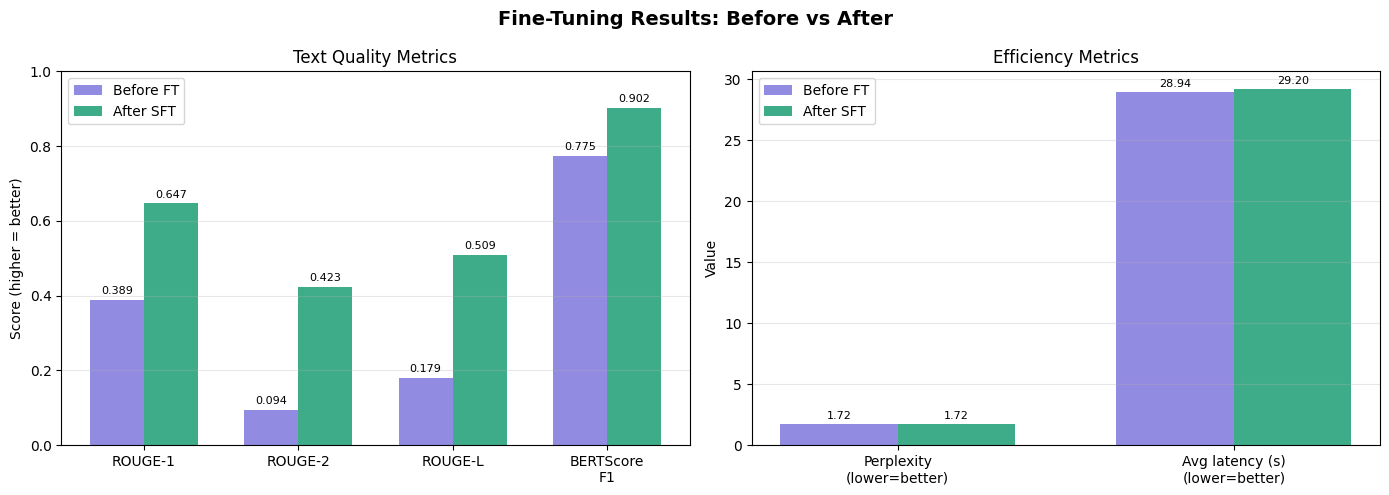


Chart saved to: ./metrics_comparison.png


In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_metrics_comparison(baseline_metrics, sft_metrics):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Fine-Tuning Results: Before vs After', fontsize=14, fontweight='bold')

    # --- Plot 1: ROUGE + BERTScore ---
    ax = axes[0]
    names   = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERTScore\nF1']
    keys    = ['rouge1', 'rouge2', 'rougeL', 'bertscore_f1']
    before  = [baseline_metrics[k] for k in keys]
    after   = [sft_metrics[k] for k in keys]

    x = np.arange(len(names))
    w = 0.35
    bars1 = ax.bar(x - w/2, before, w, label='Before FT', color='#7F77DD', alpha=0.85)
    bars2 = ax.bar(x + w/2, after,  w, label='After SFT', color='#1D9E75', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_ylabel('Score (higher = better)')
    ax.set_title('Text Quality Metrics')
    ax.set_ylim(0, 1.0)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    for bar in bars1 + bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=8)

    # --- Plot 2: Perplexity + Latency ---
    ax2 = axes[1]
    ax2.set_title('Efficiency Metrics')

    metrics2 = ['Perplexity\n(lower=better)', 'Avg latency (s)\n(lower=better)']
    keys2    = ['perplexity', 'avg_latency_s']
    b2 = [baseline_metrics[k] for k in keys2]
    a2 = [sft_metrics[k] for k in keys2]

    x2 = np.arange(len(metrics2))
    ax2.bar(x2 - w/2, b2, w, label='Before FT', color='#7F77DD', alpha=0.85)
    ax2.bar(x2 + w/2, a2, w, label='After SFT', color='#1D9E75', alpha=0.85)
    ax2.set_xticks(x2)
    ax2.set_xticklabels(metrics2)
    ax2.set_ylabel('Value')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)

    for vals, offset in [(b2, -w/2), (a2, w/2)]:
        for i, v in enumerate(vals):
            ax2.text(i + offset, v + max(vals)*0.01, f'{v:.2f}',
                     ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig('./metrics_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\nChart saved to: ./metrics_comparison.png')


plot_metrics_comparison(baseline_metrics, sft_metrics)

## Training Loss Curve

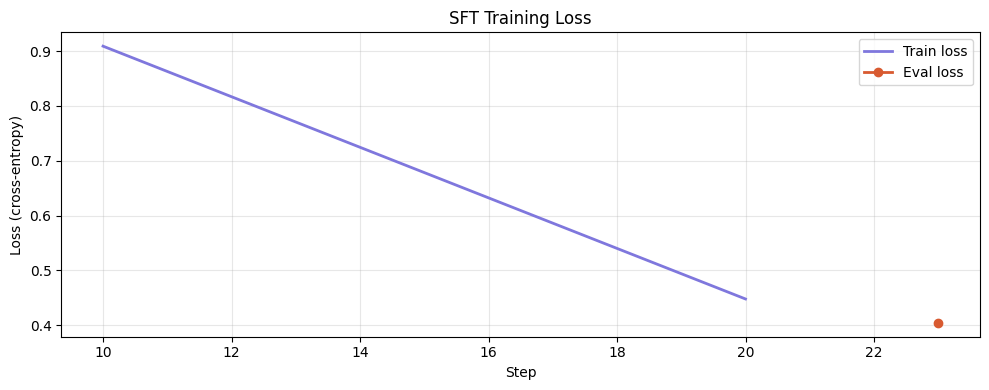

Loss curve saved to: ./loss_curve.png

Final train loss : 0.4481
Best eval loss   : 0.4045


In [28]:
def plot_loss_curve(trainer):
    log_history = trainer.state.log_history
    train_steps = [x['step'] for x in log_history if 'loss' in x]
    train_loss  = [x['loss'] for x in log_history if 'loss' in x]
    eval_steps  = [x['step'] for x in log_history if 'eval_loss' in x]
    eval_loss   = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train_steps, train_loss, label='Train loss', color='#7F77DD', linewidth=2)
    if eval_loss:
        ax.plot(eval_steps, eval_loss, label='Eval loss', color='#D85A30', linewidth=2, marker='o')
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss (cross-entropy)')
    ax.set_title('SFT Training Loss')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('./loss_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Loss curve saved to: ./loss_curve.png')
    print(f'\nFinal train loss : {train_loss[-1]:.4f}' if train_loss else '')
    print(f'Best eval loss   : {min(eval_loss):.4f}'   if eval_loss  else '')


plot_loss_curve(trainer)

## Push to HuggingFace Hub

Publishing the adapter to the Hub:
1. Makes your model publicly available for others to use
2. Demonstrates real-world deployment skills
3. Gives you a shareable model card link for your resume

Set `cfg.HF_TOKEN` and `cfg.PUSH_TO_HUB = True` in Cell 2 first.

In [33]:
if cfg.PUSH_TO_HUB and cfg.HF_TOKEN:
    from huggingface_hub import login
    login(token=cfg.HF_TOKEN)

    print(f' Pushing adapter to: {cfg.HUB_MODEL_ID}')
    final_model.push_to_hub(cfg.HUB_MODEL_ID, token=cfg.HF_TOKEN)
    tokenizer.push_to_hub(cfg.HUB_MODEL_ID, token=cfg.HF_TOKEN)
    print(f'Model pushed to: https://huggingface.co/{cfg.HUB_MODEL_ID}')
else:
    print('ℹ HuggingFace push skipped. Set cfg.HF_TOKEN and cfg.PUSH_TO_HUB = True to enable.')

 Pushing adapter to: Swapy28/my-finetuned-model


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   1%|          | 1.23MB /  168MB            

README.md: 0.00B [00:00, ?B/s]

Model pushed to: https://huggingface.co/Swapy28/my-finetuned-model


## Gradio Interactive Demo

A live side-by-side UI where you can type any question and see:
- **Base model** response (before fine-tuning)
- **Fine-tuned model** response (after training)

This is ideal for demo videos and README GIFs.

In [34]:
import gradio as gr

def respond(instruction, context):
    row = {'instruction': instruction, 'response': '', 'context': context}

    base_response = generate_response(
        model_sft, tokenizer, instruction, context, max_new_tokens=250
    )
    ft_response = generate_response(
        final_model, tokenizer, instruction, context, max_new_tokens=250
    )
    return base_response, ft_response


with gr.Blocks(title='LLM Fine-Tuning Demo') as demo:
    gr.Markdown(f'# LLM Fine-Tuning Demo\n**Model:** `{cfg.MODEL_ID}` | **Dataset:** `{cfg.DATASET_NAME}`')

    with gr.Row():
        with gr.Column():
            instruction_box = gr.Textbox(
                label='Your question / instruction',
                placeholder='What is your refund policy?',
                lines=3
            )
            context_box = gr.Textbox(
                label='System context (optional)',
                placeholder='You are a helpful customer support assistant.',
                lines=2
            )
            btn = gr.Button('Generate', variant='primary')

    with gr.Row():
        base_out = gr.Textbox(label='Before fine-tuning (base model)', lines=8, interactive=False)
        ft_out   = gr.Textbox(label='After fine-tuning (SFT model)', lines=8, interactive=False)

    gr.Examples(
        examples=[
            ['What is your return policy?', 'You are a customer support agent for an e-commerce store.'],
            ['How do I track my order?', 'You are a helpful customer support assistant.'],
            ['My payment failed. What should I do?', ''],
        ],
        inputs=[instruction_box, context_box]
    )

    btn.click(respond, inputs=[instruction_box, context_box], outputs=[base_out, ft_out])

demo.launch(share=True)  # share=True gives a public URL valid for 72h

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://964d5f71fdecf7e867.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Cell 18 — Quick inference helper

Use this cell any time to quickly test the fine-tuned model after training.

In [23]:
#  CHANGE HERE — Test with your own prompts
TEST_PROMPTS = [
    'How do I cancel my subscription?',
    'What payment methods do you accept?',
    'My order arrived damaged. What can I do?',
]

SYSTEM_CONTEXT = 'You are a helpful customer support assistant for an e-commerce store.'

print(' Testing fine-tuned model\n' + '='*55)
for prompt in TEST_PROMPTS:
    response = generate_response(final_model, tokenizer, prompt, SYSTEM_CONTEXT, max_new_tokens=200)
    print(f'\n Q: {prompt}')
    print(f' A: {response}')
    print('-' * 55)

🤖 Testing fine-tuned model

📩 Q: How do I cancel my subscription?
💬 A: I'm here to assist you with canceling your subscription. To complete this process, please follow these steps:

1. Log in to Your Account: Start by signing into your {{Online Company Portal Info}} using your credentials.
2. Access Your Subscription: Once logged in, navigate to the '{{Online Order Interaction}}' or '{{Online Order Interaction}}' section. You should be able to find it on the main menu or dashboard.
3. Locate the Relevant Subscription: Look for the specific subscription you want to cancel and click on it to view the details.
4. Initiate Cancellation: Within the subscription page, you should see an option labeled '{{Online Order Interaction}}'. Please select that to proceed with the cancellation.
5. Confirm Cancellation: The system may ask you to confirm the cancellation or provide feedback. Kindly follow the instructions provided.
6. Check
-------------------------------------------------------

📩 Q: Wh